Deliverable 01

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [3]:
df = pd.read_csv("../data/processed/hotel_reviews_cleaned.csv")

df["Review_Date"] = pd.to_datetime(df["Review_Date"])

df.head()

,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,2017-08-03,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,11,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,2017-08-03,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,105,7,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,2017-07-31,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,21,9,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,2017-07-31,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210,1403,Great location in nice surroundings the bar a...,26,1,3.8,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3 days,52.360576,4.915968
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,2017-07-24,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140,1403,Amazing location and building Romantic setting,8,3,6.7,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10 days,52.360576,4.915968


### Business Question

How have guest review scores changed over time?

### Why a Line Chart?

A line chart is the best choice for displaying trends over time. It allows businesses to identify seasonal patterns, improvements, or declines in customer satisfaction that may require operational changes.

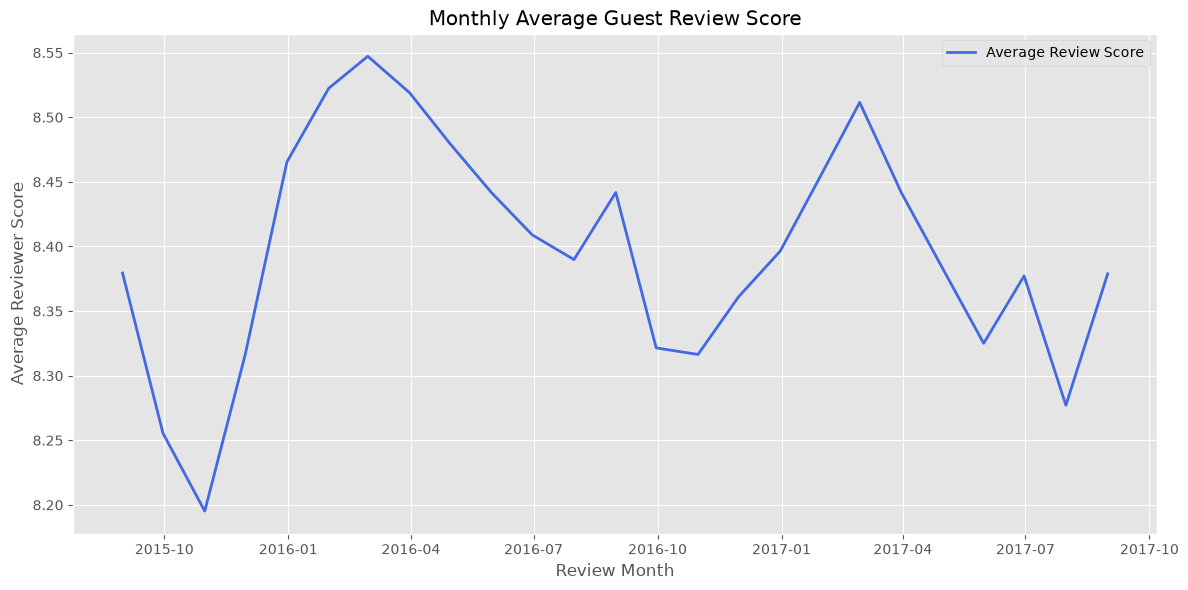

In [13]:
monthly_scores = (
    df.set_index("Review_Date")
      .resample("ME")["Reviewer_Score"]
      .mean()
)

plt.figure(figsize=(12,6))

plt.plot(
    monthly_scores.index,
    monthly_scores.values,
    color="royalblue",
    linewidth=2,
    label="Average Review Score"
)

plt.title("Monthly Average Guest Review Score")
plt.xlabel("Review Month")
plt.ylabel("Average Reviewer Score")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../visuals/charts/W3_Chart1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Business Question

Which hotels receive the highest number of guest reviews?

### Why a Bar Chart?

A bar chart is ideal for comparing categories. It clearly shows which hotels generate the most customer feedback, helping identify highly popular properties and those with greater customer engagement.

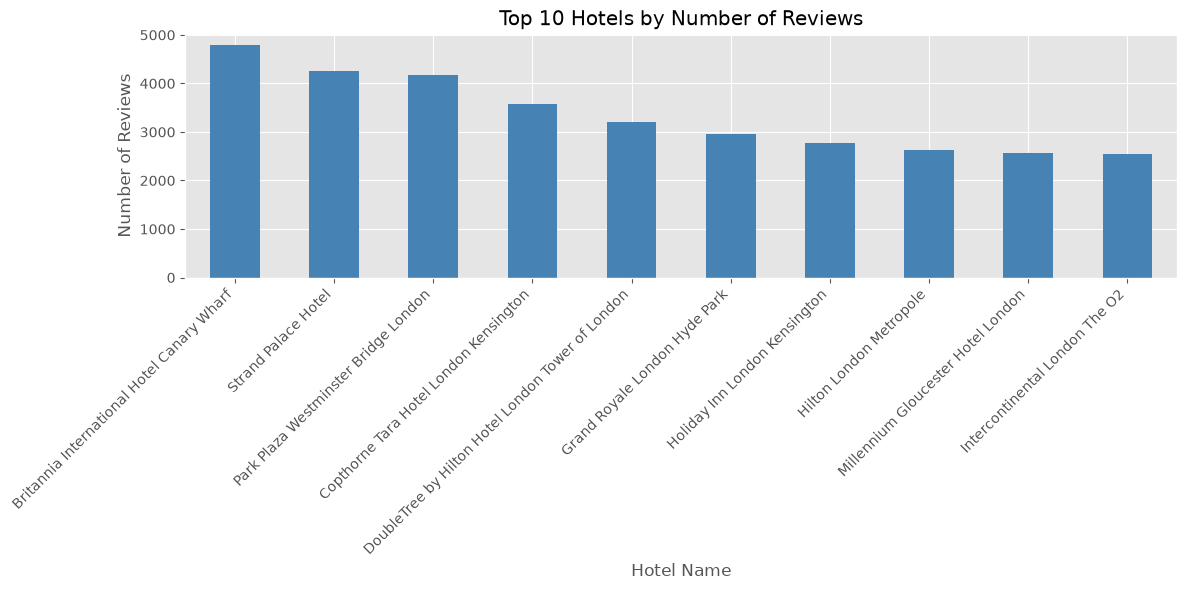

In [14]:
top_hotels = (
    df["Hotel_Name"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

top_hotels.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Top 10 Hotels by Number of Reviews")
plt.xlabel("Hotel Name")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    "../visuals/charts/W3_Chart2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Business Question

Which reviewer nationalities contribute the largest share of reviews?

### Why a Pie Chart?

A pie chart is suitable for showing the proportion of a whole. Since only the top five reviewer nationalities are displayed, it clearly illustrates which customer groups contribute the largest share of reviews.

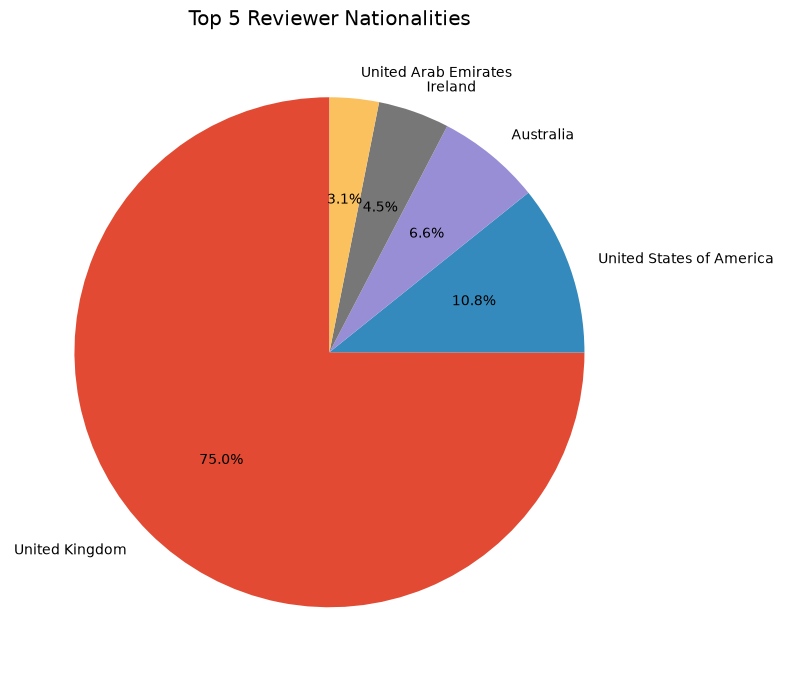

In [10]:
top5_nationalities = (
    df["Reviewer_Nationality"]
    .value_counts()
    .head(5)
)

plt.figure(figsize=(8,8))

plt.pie(
    top5_nationalities,
    labels=top5_nationalities.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 5 Reviewer Nationalities")

plt.tight_layout()
plt.show()

### Business Question

Do guests who write longer positive reviews tend to give higher ratings?

### Why a Scatter Plot?

A scatter plot is ideal for exploring relationships between two numerical variables. It helps identify whether guests who write longer positive reviews generally give higher ratings or if there is little correlation between review length and satisfaction.

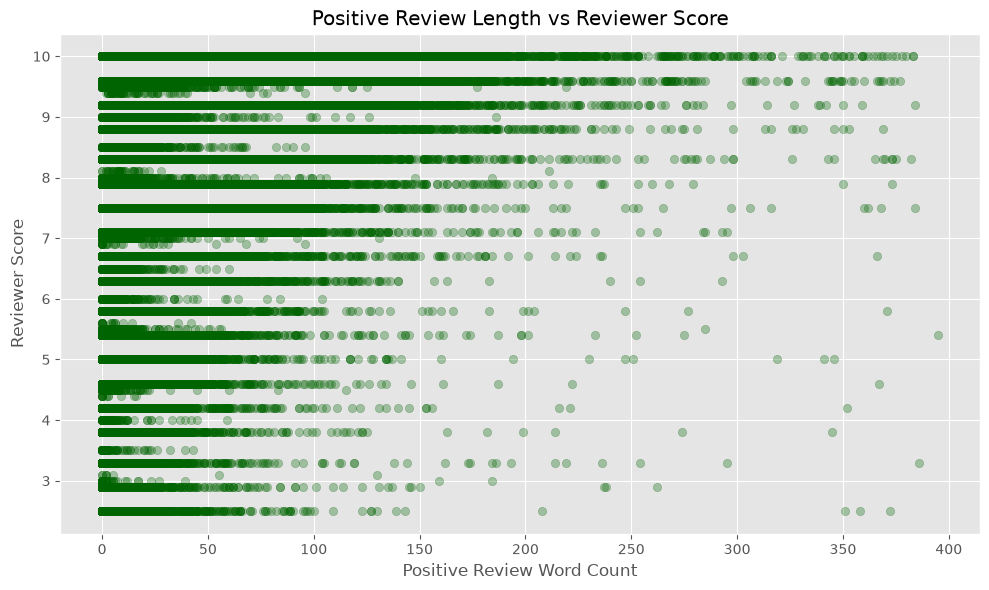

In [11]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Review_Total_Positive_Word_Counts"],
    df["Reviewer_Score"],
    alpha=0.3,
    color="darkgreen"
)

plt.title("Positive Review Length vs Reviewer Score")
plt.xlabel("Positive Review Word Count")
plt.ylabel("Reviewer Score")

plt.tight_layout()
plt.show()

### Business Question

Which numerical variables are most strongly correlated with reviewer scores?

### Why a Heatmap?

A heatmap is the best visualization for displaying correlations between multiple numerical variables simultaneously. It helps identify strong positive or negative relationships that can guide business decisions, such as understanding which factors are most closely associated with higher guest ratings.

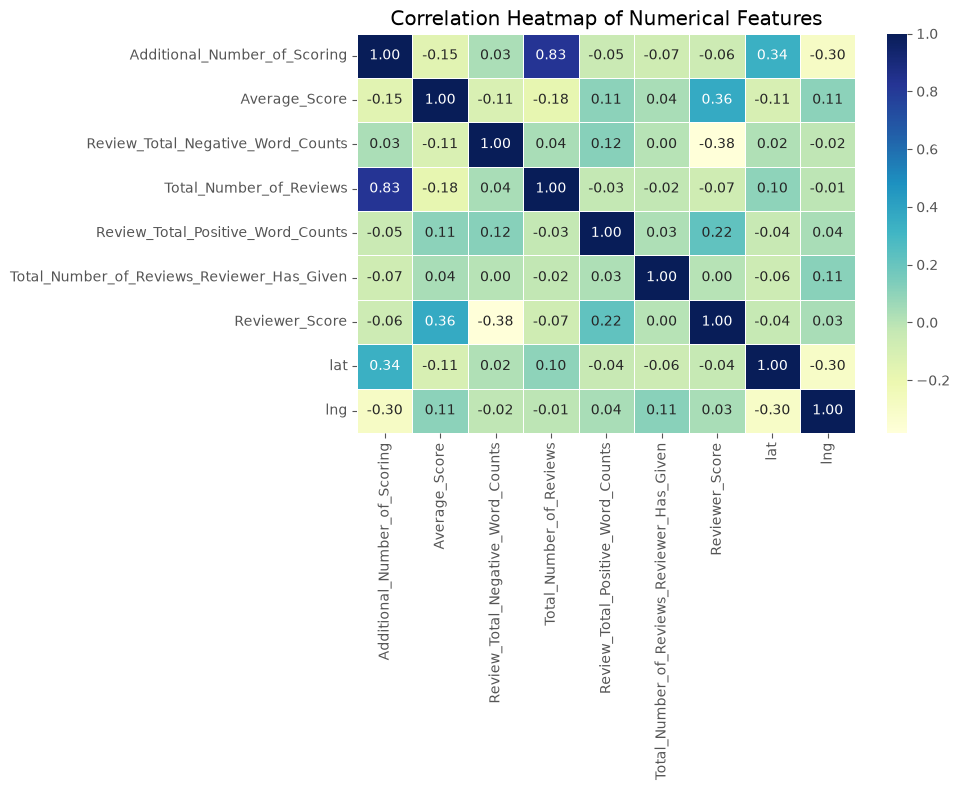

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=["int64", "float64"])

correlation = numeric_df.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")

plt.tight_layout()

plt.savefig(
    "../visuals/charts/W3_Chart3.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()